In [1]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import torch

In [2]:
words = open('Indian_Names.txt', 'r').read().splitlines()
words[:8]

['aabid', 'aabida', 'aachal', 'aadesh', 'aadil', 'aadish', 'aaditya', 'aaenab']

In [3]:
len(words)

6483

In [4]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

In [5]:
#build the dataset

block_size = 3 #Context- How many Characters do we need to predict the next one?
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->' , itos[ix])
        context = context[1:] + [ix]
        
X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([47671, 3]), torch.int64, torch.Size([47671]), torch.int64)

In [7]:
def build_dataset(words):
    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

    

torch.Size([38124, 3]) torch.Size([38124])
torch.Size([4788, 3]) torch.Size([4788])
torch.Size([4759, 3]) torch.Size([4759])


In [8]:
C = torch.randn((27, 2))

In [9]:
emb = C[X]
emb.shape

torch.Size([47671, 3, 2])

In [10]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [11]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h

tensor([[ 0.1387,  0.7205, -0.9662,  ..., -0.8781,  0.7973, -0.9972],
        [ 0.1387,  0.7239, -0.9720,  ..., -0.8773,  0.7675, -0.9978],
        [ 0.1191,  0.7788, -0.9767,  ..., -0.9066,  0.8360, -0.9981],
        ...,
        [ 0.9889,  0.9675,  0.9713,  ..., -0.9991,  0.7120, -0.8344],
        [-0.4901,  0.5794,  0.9965,  ...,  0.0299,  0.3629,  0.9906],
        [-0.9154, -0.7617,  0.8414,  ...,  0.9990, -0.9995,  0.1566]])

In [12]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [13]:
logits = h @ W2 + b2

In [14]:
logits.shape

torch.Size([47671, 27])

In [15]:
counts = logits.exp()

In [16]:
prob = counts/counts.sum(1, keepdims=True)

In [17]:
prob.shape

torch.Size([47671, 27])

In [18]:
Xtr.shape, Ytr.shape

(torch.Size([38124, 3]), torch.Size([38124]))

In [19]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [20]:
sum(p.nelement() for p in parameters)

11897

In [21]:
for p in parameters:
    p.requires_grad = True

In [22]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [23]:
lri = []
lossi = []
stepi = []

In [24]:
for i in range(200000):

    #mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    
    # print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
        
    loss.backward()
    #update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats    
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

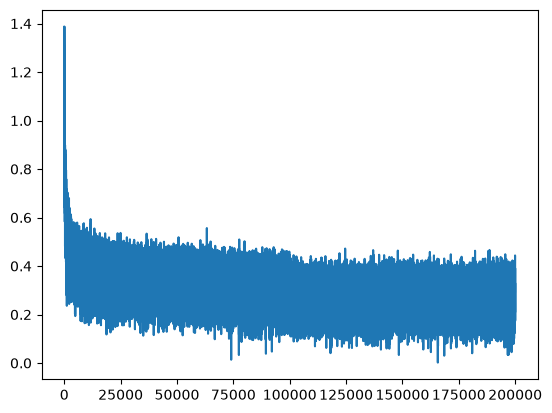

In [25]:
plt.plot(stepi, lossi)

In [26]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.8752, grad_fn=<NllLossBackward0>)

In [27]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1882, grad_fn=<NllLossBackward0>)

In [28]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))    

chamahfarjesmikhkwati.
rehty.
salash.
sha.
hushadhesriti.
geet.
neetaratchaiiy.
panej.
puham.
posh.
faijna.
roj.
ram.
vabhimattam.
devrani.
fakeeni.
sab.
sadi.
sidhataslursh.
aahida.
